In [43]:
import numpy as np
import torch
from train_reinforce import BinPacking_Environment, get_action_from_idx
from PackingUtils import *
from ModelEMS import *
import datetime
import random
import json
import seaborn as sns
import matplotlib.pyplot as plt

In [44]:
def run_policy(item_list, model_filename, device_name, clip_num=50):
	device = torch.device(device_name)
	model = BPP_Model_EMS(num_placement=clip_num, batch_size=1, embed_size=128, feature_mlp_layers=[256, 128], feature_mlp_output=64).to(device)
	model.load_state_dict(torch.load(model_filename, map_location=device, weights_only=True))
	max_steps = 200
	used_bins_idx = []

	env = BinPacking_Environment((100, 100, 100), item_list, clip_num=clip_num, device=device_name)
	step_cnt = 0
	done = False
	states, action_ids, rewards, actions = [], [], [], []
	while not done:
		placement, item_info, height_map, feasibility_mask = env.get_state()
		ems_state, item_state, ems_feature, item_feature, logits_raw_, logits = model(
			placement,
			item_info,
			height_map,
			feasibility_mask
		)
		# print(feasibility_mask)
		# print(logits)
		# if torch.any(logits < 0) or torch.any(logits == torch.nan) or torch.any(logits == torch.inf):
		# 	print(f"logits < 0 exists")
		# 	print(logits)
		# print(logits)
		try:
			action_idx = torch.multinomial(logits, 1).item()
			# action_idx = torch.topk(logits, 1, dim=-1).indices[0].item()
			# print(logits)
		except Exception as e:
			print(f"Error: {e}")
			print(item_list)
			print(logits)
			print(logits_raw_)
			print("feasibility mask: ", feasibility_mask)
			print("placement: ", placement)
			print("item_info: ", item_info)
			print("EMS state: ", ems_state)
			print("Item state: ", item_state)
			print("height_map: ", height_map)

			print("EMS feature: ", ems_feature)
			print("Item feature: ", item_feature)
			print("step count: ", step_cnt)
			break
		# print(action_idx)
		item_size = item_info.cpu().detach().numpy()[0, 0].astype(int).tolist()
		# print(item_size, item_size[0])
		action = get_action_from_idx(placement, action_idx, clip_num, height_map=env.height_map, item_size=item_size, return_height=True)
		ax, ay, ar, height = action
		reward, done = env.step((ax, ay, ar), False)
		if reward == 0:
			print(f"skip this step: item {item_info.cpu().detach().numpy().tolist()}")
			env.item_ptr += 1
			if env.item_ptr >= len(item_list):
				done = True
		else:
			states.append((placement, item_state, height_map, feasibility_mask))
			rewards.append(reward)
			action_ids.append(action_idx)
			actions.append(action)
			if env.item_ptr not in used_bins_idx:
				used_bins_idx.append(env.item_ptr)
		if step_cnt >= max_steps and not done:
			done = True
			# rewards[-1] -= env.get_remaining_cnt() * 0.1
			break
		step_cnt += 1
	print(f"Used items: {env.used} / {len(env.items_list)}")
	return env, used_bins_idx, actions

In [45]:

items = np.load("dataset_map/item_list.npy")
# print(items)
item_list_ = items.tolist()
print(item_list_)
item_list = []
for item in item_list_:
	item_list.append(np.array(item))
# train()
item_list.sort(key=lambda x: max(x[0], x[1]), reverse=True)
print(item_list)
# random.shuffle(item_list)


[[27, 41, 29], [27, 17, 29], [12, 11, 20], [9, 12, 29], [18, 3, 29], [32, 2, 10], [32, 11, 29], [32, 24, 29], [8, 1, 29], [6, 47, 29], [4, 11, 9], [8, 11, 9], [26, 33, 29], [26, 30, 13], [28, 96, 71], [29, 42, 3], [29, 37, 26], [29, 5, 26], [13, 3, 8], [8, 28, 29], [8, 13, 29], [2, 2, 19], [30, 2, 19], [12, 23, 27], [3, 27, 29], [12, 9, 29], [12, 15, 29], [26, 17, 16], [6, 16, 17], [3, 16, 12], [3, 16, 12], [13, 3, 2], [13, 3, 19], [18, 4, 47], [18, 4, 24], [28, 27, 22], [28, 27, 7], [39, 4, 71], [43, 4, 71], [29, 11, 29], [1, 12, 29], [21, 12, 29], [24, 96, 71], [48, 96, 71], [12, 13, 2], [12, 10, 2], [26, 4, 16], [26, 9, 16], [12, 47, 29], [17, 47, 29]]
[array([28, 96, 71]), array([24, 96, 71]), array([48, 96, 71]), array([ 6, 47, 29]), array([12, 47, 29]), array([17, 47, 29]), array([43,  4, 71]), array([29, 42,  3]), array([27, 41, 29]), array([39,  4, 71]), array([29, 37, 26]), array([26, 33, 29]), array([32,  2, 10]), array([32, 11, 29]), array([32, 24, 29]), array([26, 30, 13]),

In [46]:
env, used_bins_idx, actions = run_policy(item_list, "checkpoints/model_290.pth", "cpu")
print(used_bins_idx)
print(actions)

[28, 96, 71] [95  0  0]
find height:  0.0
Update Height Map: area_max_height = 0.0, bin height = 71, sum = 71.0
[24, 96, 71] [99 28  0]
find height:  0.0
Update Height Map: area_max_height = 0.0, bin height = 71, sum = 71.0
[48, 96, 71] [99 52  0]
find height:  0.0
Update Height Map: area_max_height = 0.0, bin height = 71, sum = 71.0
[6, 47, 29] [46  0 71]
find height:  71.0
Update Height Map: area_max_height = 71.0, bin height = 29, sum = 100.0
[12, 47, 29] [99 53 71]
find height:  71.0
Update Height Map: area_max_height = 71.0, bin height = 29, sum = 100.0
[17, 47, 29] [ 99   0 100]
find height:  71.0
Update Height Map: area_max_height = 71.0, bin height = 29, sum = 100.0
[43, 4, 71] [ 3 57  0]
find height:  0.0
Update Height Map: area_max_height = 0.0, bin height = 71, sum = 71.0
[29, 42, 3] [88 24 71]
find height:  71.0
Update Height Map: area_max_height = 71.0, bin height = 3, sum = 74.0
[27, 41, 29] [40  0 71]
find height:  71.0
Update Height Map: area_max_height = 71.0, bin heig

In [47]:
height_map = env.height_map
state = None
if env.item_ptr == len(item_list):
	print("success")
else:
	coming_item = env.items_list[env.item_ptr]
	print(f"coming item: {coming_item}")
	states = env.get_state()
utilization = env.get_utilization()
print(f"utilization: {utilization}")

success
utilization: 0.905028


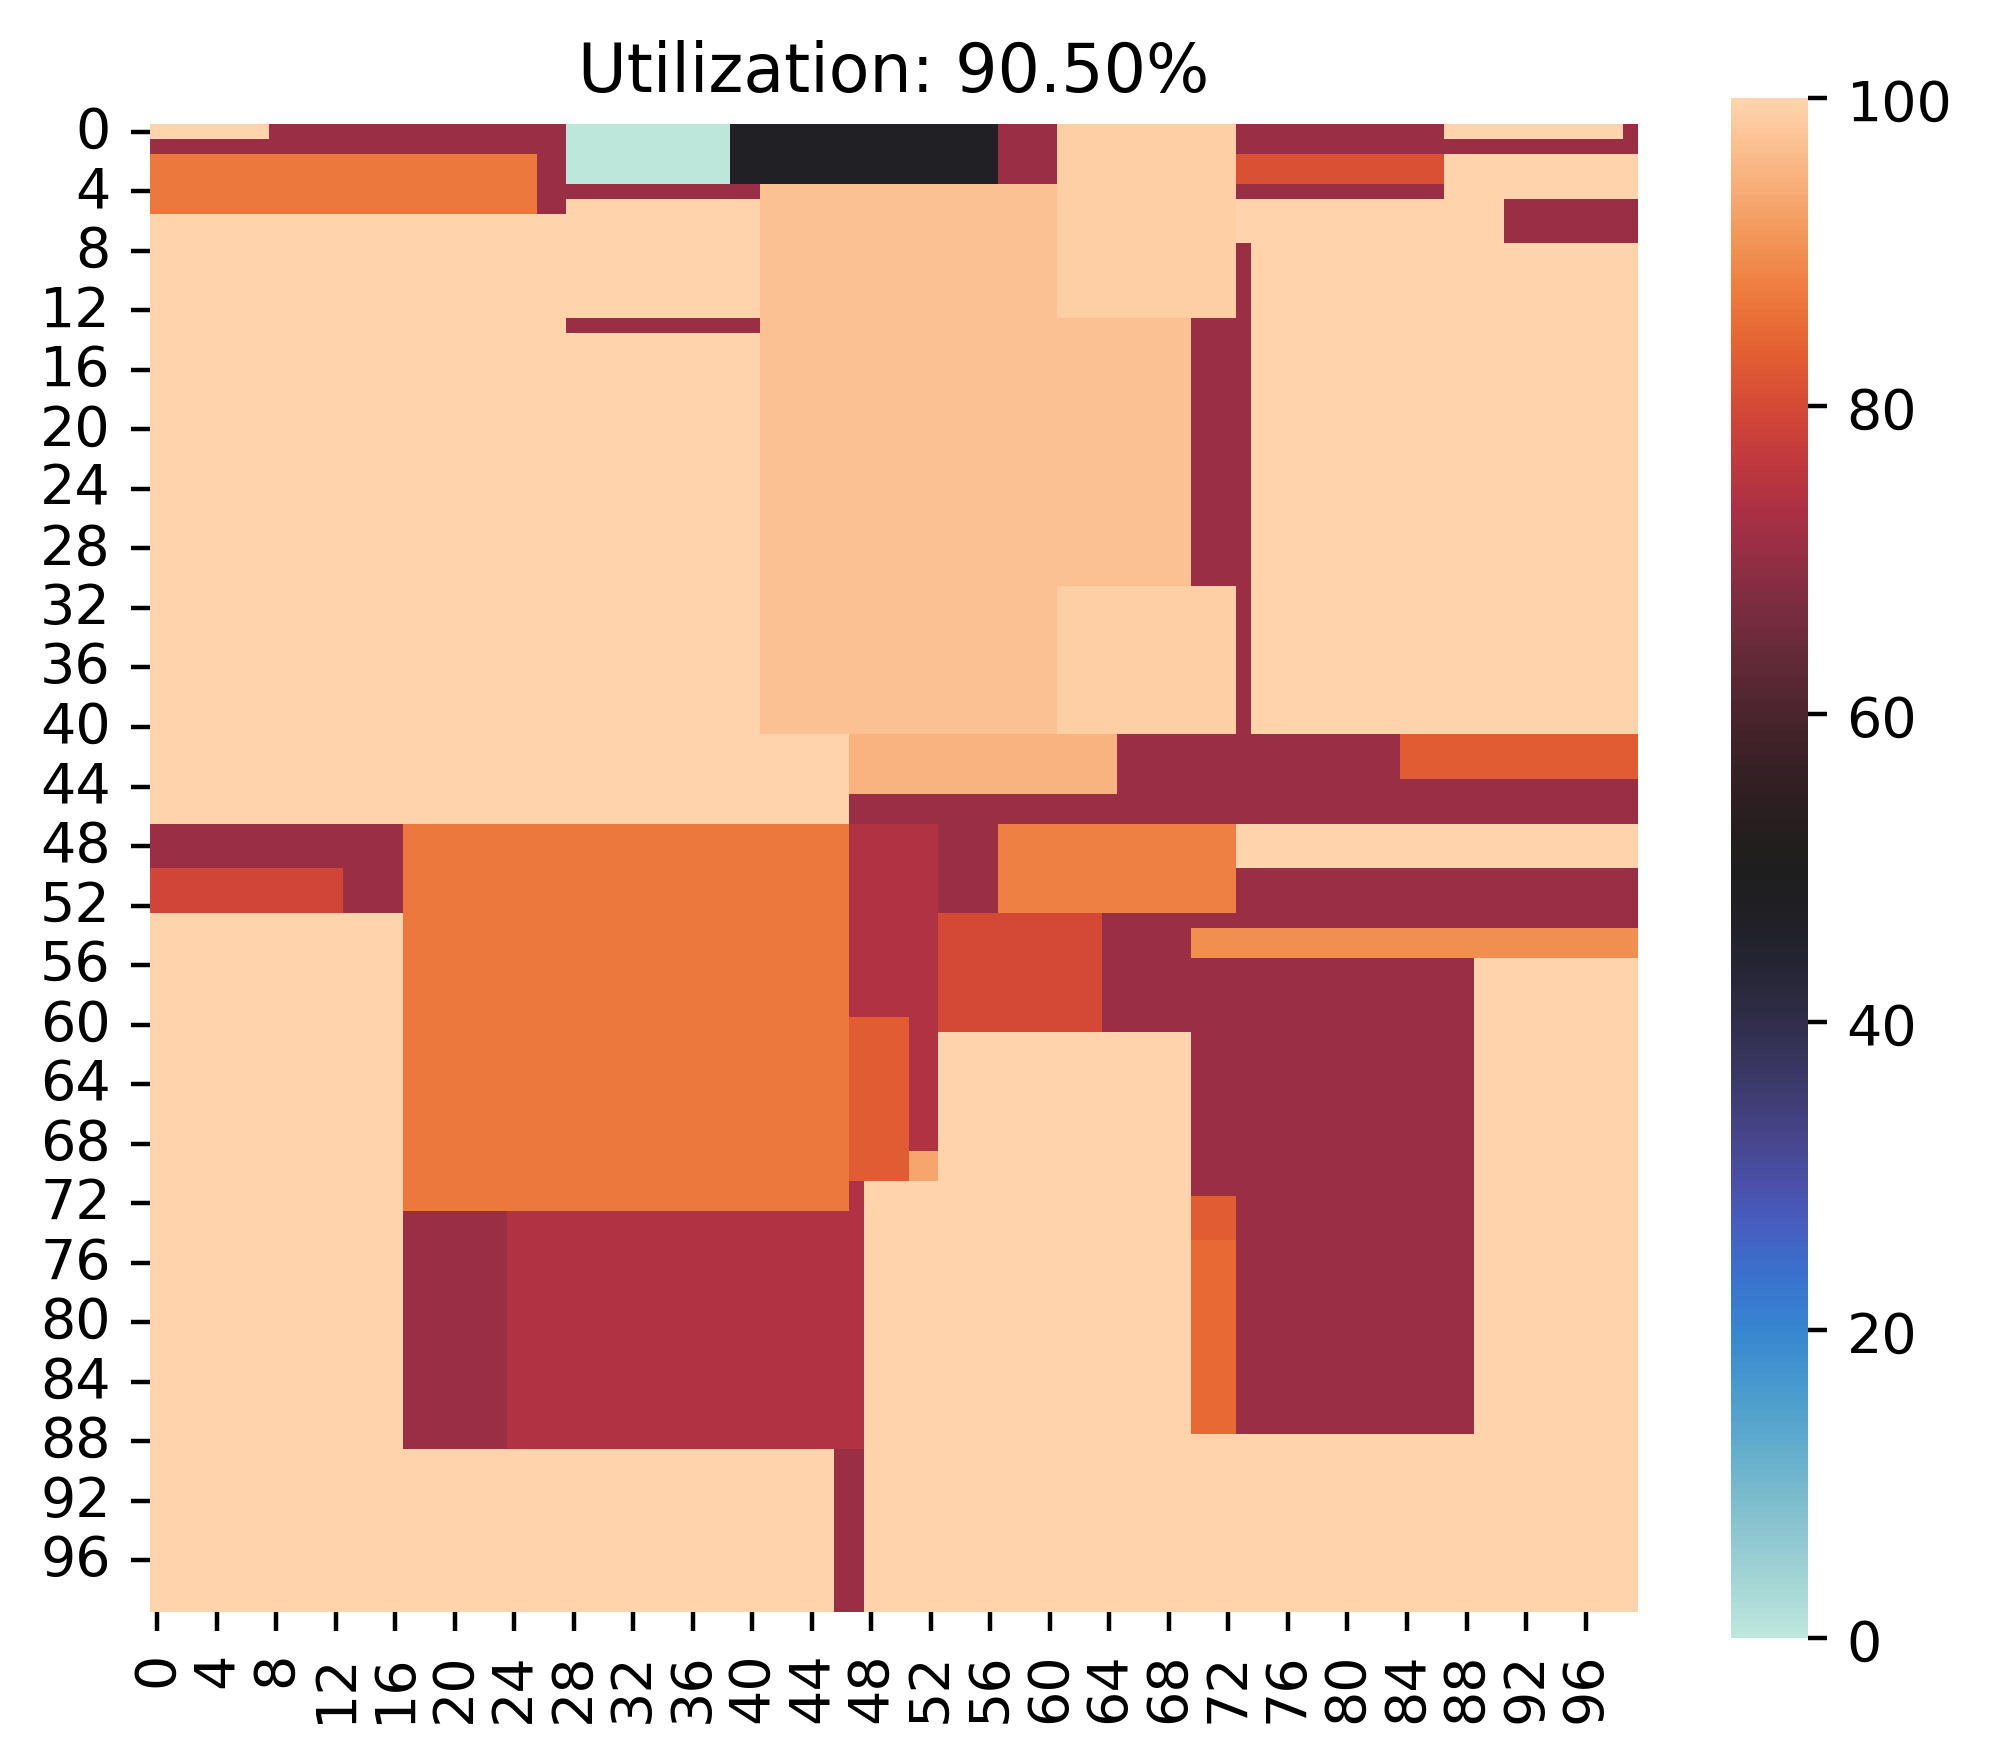

In [48]:
fig = plt.figure(figsize=(6, 5), dpi=400)
sns.heatmap(height_map, square=True, center=50)
plt.title("Utilization: {:.2f}%".format(utilization*100))
plt.savefig("test_bin_packing.png")

In [49]:
if state:
	print(f"placement: {states[0]}")

In [85]:
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
fig = plt.figure(figsize=(6, 5), dpi=100)

def draw_bins_3d(positions, sizes, filename):
    """
    Draws a 3D figure of bins given their positions and sizes.

    Parameters:
    - positions: List of tuples (x, y, z) representing the bottom-left-front corner of each bin.
    - sizes: List of tuples (dx, dy, dz) representing the dimensions of each bin.
    """
    fig = plt.figure(figsize=(6, 5), dpi=400)
    ax = fig.add_subplot(111, projection='3d')
    nums = len(positions)
    ranges = [random.random() for _ in range(nums)]
    print(ranges)
    color_list = plt.cm.tab20b(ranges)

    for i, (pos, size) in enumerate(zip(positions, sizes)):
        x, y, z = pos
        dx, dy, dz = size
        facecolor = color_list[i]

        # Define the vertices of the cuboid
        vertices = [
            [x, y, z],
            [x-dx, y, z],
            [x-dx, y+dy, z],
            [x, y+dy, z],
            [x, y, z+dz],
            [x-dx, y, z+dz],
            [x-dx, y+dy, z+dz],
            [x, y+dy, z+dz],
        ]

        # Define the 12 edges of the cuboid
        edges = [
            [vertices[0], vertices[1], vertices[2], vertices[3]],  # Bottom face
            [vertices[4], vertices[5], vertices[6], vertices[7]],  # Top face
            [vertices[0], vertices[1], vertices[5], vertices[4]],  # Front face
            [vertices[2], vertices[3], vertices[7], vertices[6]],  # Back face
            [vertices[1], vertices[2], vertices[6], vertices[5]],  # Right face
            [vertices[0], vertices[3], vertices[7], vertices[4]],  # Left face
        ]

        # Add the cuboid to the plot
        ax.add_collection3d(Poly3DCollection(edges, alpha=1.0, edgecolor='k', facecolor=facecolor, linewidth=0.1))

    # Set axes limits and labels
    max_dim = max(max(pos[i] + size[i] for pos, size in zip(positions, sizes)) for i in range(3))
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)
    ax.set_zlim(0, 100)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')

    # plt.show()
    plt.savefig(filename)

# Example usage
# positions = [(0, 0, 0), (1, 1, 1), (2, 2, 2)]  # Bottom-left-front positions of bins
# sizes = [(1, 1, 1), (1, 2, 1), (2, 1, 2)]  # Dimensions (dx, dy, dz) of each bin

# draw_bins_3d(positions, sizes)

<Figure size 600x500 with 0 Axes>

[[28, 96, 71], [24, 96, 71], [48, 96, 71], [6, 47, 29], [12, 47, 29], [17, 47, 29], [43, 4, 71], [29, 42, 3], [27, 41, 29], [29, 37, 26], [26, 33, 29], [32, 2, 10], [32, 11, 29], [26, 30, 13], [30, 2, 19], [29, 5, 26], [29, 11, 29], [8, 28, 29], [27, 17, 29], [3, 27, 29], [26, 4, 16], [18, 3, 29], [18, 4, 47], [18, 4, 24], [6, 16, 17], [3, 16, 12], [3, 16, 12], [13, 3, 8], [8, 13, 29], [13, 3, 2], [13, 3, 19], [12, 13, 2], [1, 12, 29], [12, 10, 2], [4, 11, 9], [8, 11, 9], [8, 1, 29], [2, 2, 19]]
[[95, 0, 0.0], [99, 28, 0.0], [99, 52, 0.0], [46, 0, 71.0], [99, 53, 71.0], [99, 0, 71.0], [3, 57, 0.0], [88, 24, 71.0], [40, 0, 71.0], [40, 41, 71.0], [40, 74, 71.0], [3, 68, 71.0], [87, 89, 71.0], [72, 17, 74.0], [55, 70, 71.0], [99, 48, 74.0], [99, 17, 71.0], [13, 0, 71.0], [87, 53, 71.0], [49, 73, 71.0], [5, 0, 71.0], [7, 73, 71.0], [3, 39, 0.0], [44, 47, 71.0], [52, 57, 71.0], [87, 70, 71.0], [43, 84, 71.0], [52, 0, 71.0], [12, 28, 71.0], [87, 70, 83.0], [4, 87, 81.0], [12, 61, 97.0], [0, 

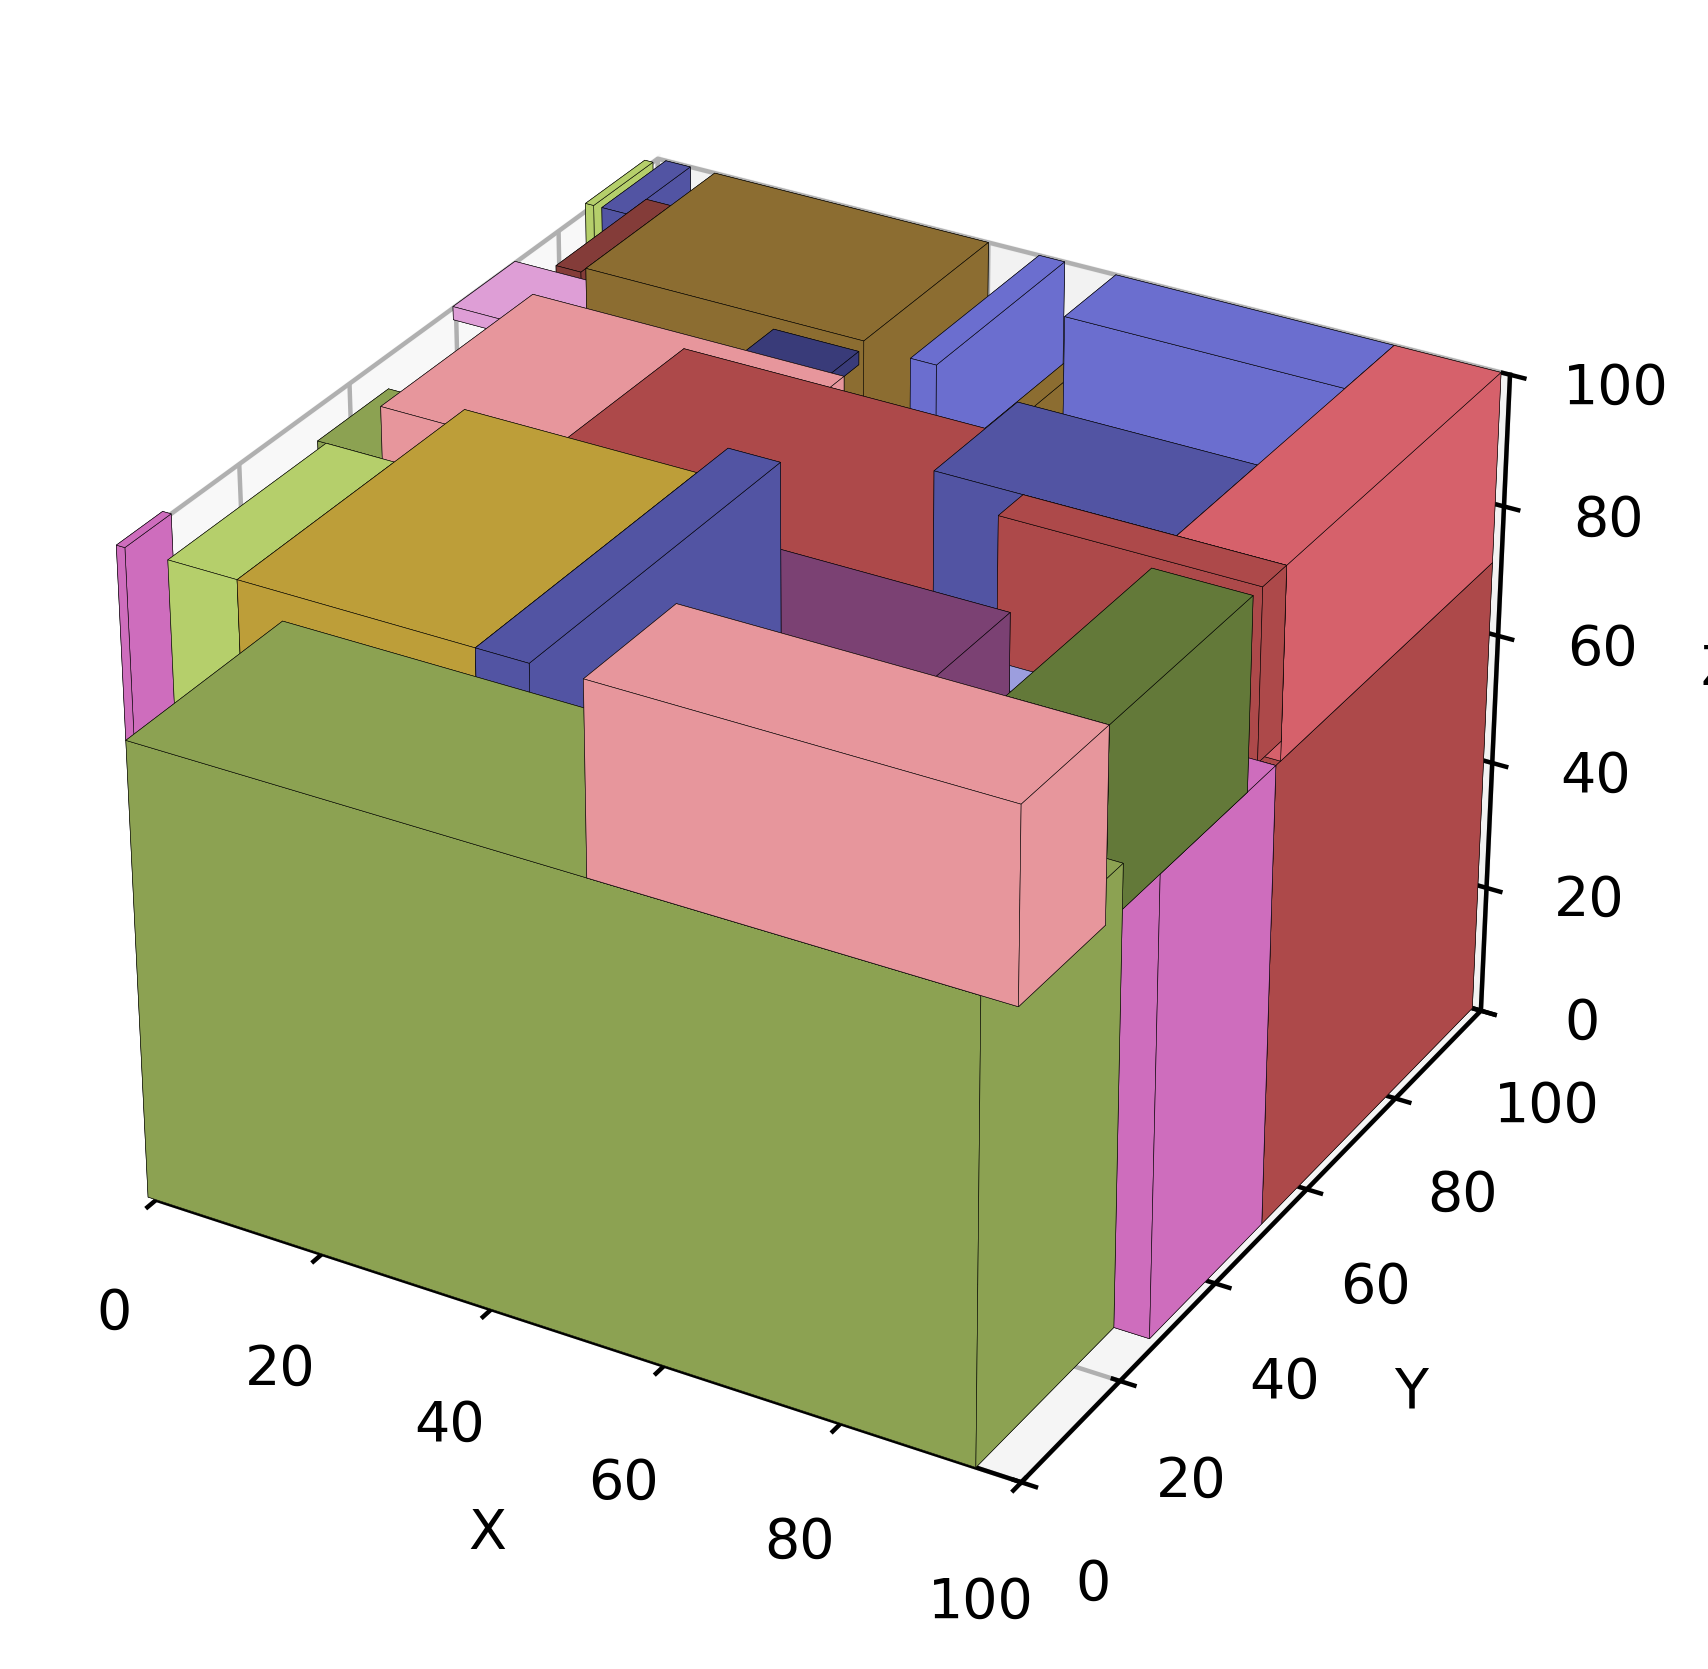

In [87]:

# ax = fig.add_subplot(111, projection='3d')

bins = [item_list[idx-1].tolist() for idx in used_bins_idx]
positions = []
print(bins)
n_used_bins = len(used_bins_idx)
for i in range(n_used_bins):
	xpos, ypos, rotate, zpos = actions[i]
	if rotate == 1:
		bins[i] = [bins[i][1], bins[i][0], bins[i][2]]
	positions.append([xpos, ypos, zpos])
print(positions)
# ax.voxels(bins, edgecolor='k')
draw_bins_3d(positions, bins, "models/bin_packing_3d.png")